In [1]:
!pip install -q git+https://github.com/brandonstarxel/chunking_evaluation.git
!pip install -q backoff sentence-transformers transformers matplotlib seaborn tqdm

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 10.5 MB/s eta 0:00:00
   ━━━━

In [2]:
import os

USER_REPO_URL = "https://github.com/Dhanashri-R/TrendsInNLP_chunking-evaluation-project.git"
USER_REPO_DIR = "/content/legal_domain_repo"

if not os.path.exists(USER_REPO_DIR):
    !git clone --depth 1 {USER_REPO_URL} {USER_REPO_DIR}
else:
    print("Repo already cloned.")


Cloning into '/content/legal_domain_repo'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 34 (delta 2), reused 34 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 678.85 KiB | 2.11 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
import os
import time
import json
from pathlib import Path
from importlib import resources

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from tqdm.auto import tqdm

from chromadb.utils import embedding_functions

from chunking_evaluation.chunking import (
    FixedTokenChunker,
    RecursiveTokenChunker,
    ClusterSemanticChunker,
)
from chunking_evaluation.evaluation_framework.base_evaluation import BaseEvaluation
from chunking_evaluation.utils import (
    openai_token_count,
    rigorous_document_search,
)

sns.set_theme(style="whitegrid", context="talk")

os.makedirs("/content/results", exist_ok=True)
os.makedirs("/content/figures", exist_ok=True)

In [4]:
with resources.as_file(
    resources.files("chunking_evaluation.evaluation_framework") / "general_evaluation_data"
) as _p:
    GENERAL_DATA_PATH = Path(_p)

paper_questions_df = pd.read_csv(GENERAL_DATA_PATH / "questions_df.csv")
wiki_df = paper_questions_df[paper_questions_df["corpus_id"] == "wikitexts"].copy()
finance_df = paper_questions_df[paper_questions_df["corpus_id"] == "finance"].copy()

legal_questions_path = Path(USER_REPO_DIR) / "evaluation_framework" / "general_evaluation_data" / "legal_questions.csv"
legal_df = pd.read_csv(legal_questions_path)

merged_questions_df = pd.concat([wiki_df, finance_df, legal_df], ignore_index=True)
MERGED_QUESTIONS_CSV = "/content/merged_questions.csv"
merged_questions_df.to_csv(MERGED_QUESTIONS_CSV, index=False)

CORPORA_ID_PATHS = {
    "wikitexts": str(GENERAL_DATA_PATH / "corpora" / "wikitexts.md"),
    "finance":   str(GENERAL_DATA_PATH / "corpora" / "finance.md"),
    "legal":     str(Path(USER_REPO_DIR) / "evaluation_framework" / "general_evaluation_data" / "corpora" / "legal.md"),
}

print(merged_questions_df["corpus_id"].value_counts())
merged_questions_df.head(3)


corpus_id
wikitexts    144
finance       97
legal         79
Name: count, dtype: int64


,question,references,corpus_id
0,What adaptations were made based on the game V...,"[{""content"": "" Valkyria Chronicles 3 was adapt...",wikitexts
1,What actions were taken by Captain Totten in r...,"[{""content"": ""Perhaps because Abraham Lincoln ...",wikitexts
2,Why wasn't Valkyria Chronicles III released in...,"[{""content"": ""Unlike its two predecessors , Va...",wikitexts


In [5]:
EMBEDDING_MODELS = {
    "MiniLM-L6-v2": {
        "hf_name": "sentence-transformers/all-MiniLM-L6-v2",
        "chunk_sizes": [200, 250],
    },
    "BGE-small-en-v1.5": {
        "hf_name": "BAAI/bge-small-en-v1.5",
        "chunk_sizes": [200, 250],
    },
}

for name, cfg in EMBEDDING_MODELS.items():
    print(f"{name:20s} chunk_sizes={cfg['chunk_sizes']}")

MiniLM-L6-v2         chunk_sizes=[200, 250]
BGE-small-en-v1.5    chunk_sizes=[200, 250]


In [6]:
class SafeChunker:
    """
    Generic wrapper for ANY chunker used in this notebook.

    Why this is needed
    ------------------
    Chroma's evaluation code maps each returned chunk back to a character
    span in the original document using rigorous_document_search().

    Some upstream chunkers can occasionally emit punctuation-only fragments
    such as ".". Chroma's matcher strips a trailing period before searching;
    "." therefore becomes an empty string and maps to a zero-length span
    (start == end). If such a chunk is retrieved, the upstream precision
    denominator can become zero and raise ZeroDivisionError.

    This wrapper does NOT change the underlying chunking algorithm.
    It simply removes chunks that Chroma's own span matcher considers
    zero-length.

    It is applied to Fixed, Recursive, and ClusterSemantic uniformly.
    """

    def __init__(self, base_chunker):
        self.base_chunker = base_chunker

    def split_text(self, text):
        chunks = self.base_chunker.split_text(text)
        valid_chunks = []

        for chunk in chunks:
            if not chunk or not chunk.strip():
                continue

            _, start, end = rigorous_document_search(text, chunk)

            if end > start:
                valid_chunks.append(chunk)

        if not valid_chunks:
            raise RuntimeError(
                f"{self.base_chunker.__class__.__name__} produced no valid chunks."
            )

        return valid_chunks


def build_chunkers(embedding_function, chunk_size):
    """
    Build the three chunkers.

    All chunk-size definitions use Chroma's cl100k_base convention.

    Each chunker is wrapped in SafeChunker so punctuation-only / zero-span
    fragments are removed consistently before evaluation.
    """

    fixed = FixedTokenChunker(
        encoding_name="cl100k_base",
        chunk_size=chunk_size,
        chunk_overlap=0,
    )

    recursive = RecursiveTokenChunker(
        chunk_size=chunk_size,
        chunk_overlap=0,
        length_function=openai_token_count,
        separators=["\n\n", "\n", ".", "?", "!", " ", ""],
    )

    cluster = ClusterSemanticChunker(
        embedding_function=embedding_function,
        max_chunk_size=chunk_size,
        min_chunk_size=50,
        length_function=openai_token_count,
    )

    return {
        "Fixed-length": SafeChunker(fixed),
        "Recursive": SafeChunker(recursive),
        "Cluster-semantic": SafeChunker(cluster),
    }

In [7]:
def summarize_chunk_sizes(chunks):
    lengths = [openai_token_count(c) for c in chunks]
    return (
        float(np.mean(lengths)),
        float(np.std(lengths)),
        len(lengths),
    )


evaluation = BaseEvaluation(
    MERGED_QUESTIONS_CSV,
    corpora_id_paths=CORPORA_ID_PATHS
)

corpus_texts = {
    domain: Path(path).read_text(encoding="utf-8")
    for domain, path in CORPORA_ID_PATHS.items()
}

all_rows = []


def prepare_chroma_temp_collections(evaluation):
    """
    Make BaseEvaluation compatible with newer ChromaDB WITHOUT monkey-patching.

    The upstream package tries to delete these names before recreating them.
    We guarantee that they exist first, so delete_collection succeeds.

    Safe to call repeatedly.
    """
    for collection_name in ["auto_chunk", "auto_questions"]:
        evaluation.chroma_client.get_or_create_collection(
            name=collection_name
        )


for model_key, cfg in EMBEDDING_MODELS.items():
    print(f"\n=== {model_key} ({cfg['hf_name']}) ===")

    ef = embedding_functions.SentenceTransformerEmbeddingFunction(
        model_name=cfg["hf_name"]
    )

    for chunk_size in cfg["chunk_sizes"]:
        chunkers = build_chunkers(
            embedding_function=ef,
            chunk_size=chunk_size,
        )

        for method_name, chunker in tqdm(
            chunkers.items(),
            desc=f"{model_key} @ {chunk_size} tokens"
        ):
            t0 = time.time()

            # ----------------------------------------------------------
            # Step 1: Measure what this chunker actually produced.
            # All measurements use the SAME cl100k_base convention.
            # ----------------------------------------------------------
            actual_size = {}

            for domain, text in corpus_texts.items():
                chunks = chunker.split_text(text)

                # SafeChunker has already removed any zero-length mapped
                # fragments (for example a standalone ".").
                actual_size[domain] = summarize_chunk_sizes(chunks)

            # ----------------------------------------------------------
            # Step 2: Retrieval quality.
            #
            # Prepare the temporary collections so the old evaluation code
            # can safely delete/recreate them on modern ChromaDB.
            # ----------------------------------------------------------
            prepare_chroma_temp_collections(evaluation)

            result = evaluation.run(
                chunker,
                ef,
                retrieve=5,
            )

            elapsed = time.time() - t0

            for domain, scores in result["corpora_scores"].items():
                mean_actual, std_actual, n_chunks = actual_size.get(
                    domain,
                    (np.nan, np.nan, np.nan)
                )

                all_rows.append({
                    "embedding_model": model_key,
                    "chunk_size_target": chunk_size,
                    "chunk_size_actual_mean": mean_actual,
                    "chunk_size_actual_std": std_actual,
                    "n_chunks_in_corpus": n_chunks,
                    "method": method_name,
                    "domain": domain,

                    "recall_mean": float(
                        np.mean(scores["recall_scores"])
                    ),
                    "recall_std": float(
                        np.std(scores["recall_scores"])
                    ),

                    "precision_mean": float(
                        np.mean(scores["precision_scores"])
                    ),
                    "precision_std": float(
                        np.std(scores["precision_scores"])
                    ),

                    "precision_omega_mean": float(
                        np.mean(scores["precision_omega_scores"])
                    ),
                    "precision_omega_std": float(
                        np.std(scores["precision_omega_scores"])
                    ),

                    "iou_mean": float(
                        np.mean(scores["iou_scores"])
                    ),
                    "iou_std": float(
                        np.std(scores["iou_scores"])
                    ),

                    "n_questions": len(
                        scores["recall_scores"]
                    ),
                })

            avg_actual = np.mean(
                [v[0] for v in actual_size.values()]
            )

            print(
                f"  {method_name:18s} "
                f"target={chunk_size:<4d} "
                f"actual~{avg_actual:.0f} tok  "
                f"done in {elapsed:5.1f}s"
            )

            # Save partial progress after EVERY completed configuration.
            # If Colab disconnects later, already-completed work is preserved.
            pd.DataFrame(all_rows).to_csv(
                "/content/results/chunking_eval_results_partial.csv",
                index=False,
            )


results_df = pd.DataFrame(all_rows)

results_df.to_csv(
    "/content/results/chunking_eval_results.csv",
    index=False,
)

print(
    f"\nFinished. Saved {len(results_df)} rows to "
    "/content/results/chunking_eval_results.csv"
)

results_df.head()


=== MiniLM-L6-v2 (sentence-transformers/all-MiniLM-L6-v2) ===


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BGE-small-en-v1.5 @ 200 tokens:   0%|          | 0/3 [00:00<?, ?it/s]

  Fixed-length       target=200  actual~200 tok  done in 187.1s
  Recursive          target=200  actual~135 tok  done in 206.3s
  Cluster-semantic   target=200  actual~102 tok  done in 557.1s


BGE-small-en-v1.5 @ 250 tokens:   0%|          | 0/3 [00:00<?, ?it/s]

  Fixed-length       target=250  actual~249 tok  done in 169.6s
  Recursive          target=250  actual~172 tok  done in 192.5s
  Cluster-semantic   target=250  actual~124 tok  done in 561.8s

Finished. Saved 36 rows to /content/results/chunking_eval_results.csv


,embedding_model,chunk_size_target,chunk_size_actual_mean,chunk_size_actual_std,n_chunks_in_corpus,method,domain,recall_mean,recall_std,precision_mean,precision_std,precision_omega_mean,precision_omega_std,iou_mean,iou_std,n_questions
0,MiniLM-L6-v2,200,198.873134,12.995649,134,Fixed-length,wikitexts,0.796396,0.362580,0.045406,0.031264,0.219449,0.102687,0.045136,0.031142,144
1,MiniLM-L6-v2,200,199.972323,0.797381,831,Fixed-length,finance,0.735360,0.422950,0.038854,0.040569,0.172359,0.132372,0.038720,0.040439,97
2,MiniLM-L6-v2,200,199.677885,6.561989,416,Fixed-length,legal,0.849478,0.316807,0.059946,0.051208,0.249416,0.153972,0.059513,0.050726,79
3,MiniLM-L6-v2,200,129.351220,58.117908,205,Recursive,wikitexts,0.778386,0.391660,0.065169,0.050289,0.335476,0.198707,0.064836,0.050233,144
4,MiniLM-L6-v2,200,139.728114,56.303883,1188,Recursive,finance,0.678507,0.453764,0.049049,0.049217,0.271221,0.186273,0.048947,0.049130,97


In [8]:
COLUMN_ORDER = [
    "embedding_model", "method", "domain",
    "chunk_size_target", "chunk_size_actual_mean", "chunk_size_actual_std", "n_chunks_in_corpus",
    "recall_mean", "recall_std",
    "precision_mean", "precision_std",
    "precision_omega_mean", "precision_omega_std",
    "iou_mean", "iou_std",
    "n_questions",
]

comprehensive_table = (
    results_df[COLUMN_ORDER]
    .sort_values(["embedding_model", "chunk_size_target", "method", "domain"])
    .reset_index(drop=True)
)
# Round for readability; the full-precision CSV is still saved separately.
display_table = comprehensive_table.round({
    "chunk_size_actual_mean": 1, "chunk_size_actual_std": 1,
    "recall_mean": 3, "recall_std": 3,
    "precision_mean": 3, "precision_std": 3,
    "precision_omega_mean": 3, "precision_omega_std": 3,
    "iou_mean": 3, "iou_std": 3,
})

comprehensive_table.to_csv("/content/results/comprehensive_results_table.csv", index=False)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
display_table


,embedding_model,method,domain,chunk_size_target,chunk_size_actual_mean,chunk_size_actual_std,n_chunks_in_corpus,recall_mean,recall_std,precision_mean,precision_std,precision_omega_mean,precision_omega_std,iou_mean,iou_std,n_questions
0,BGE-small-en-v1.5,Cluster-semantic,finance,200,102.3,52.9,1618,0.748,0.419,0.066,0.059,0.294,0.221,0.066,0.059,97
1,BGE-small-en-v1.5,Cluster-semantic,legal,200,93.8,50.0,885,0.839,0.312,0.102,0.088,0.445,0.259,0.100,0.086,79
2,BGE-small-en-v1.5,Cluster-semantic,wikitexts,200,109.2,45.2,242,0.826,0.332,0.080,0.053,0.363,0.182,0.079,0.052,144
3,BGE-small-en-v1.5,Fixed-length,finance,200,200.0,0.8,831,0.857,0.331,0.045,0.041,0.172,0.132,0.044,0.041,97
4,BGE-small-en-v1.5,Fixed-length,legal,200,199.7,6.6,416,0.866,0.295,0.062,0.050,0.249,0.154,0.061,0.050,79
5,BGE-small-en-v1.5,Fixed-length,wikitexts,200,198.9,13.0,134,0.874,0.284,0.050,0.030,0.219,0.103,0.050,0.030,144
6,BGE-small-en-v1.5,Recursive,finance,200,139.7,56.3,1188,0.752,0.415,0.056,0.057,0.271,0.186,0.056,0.057,97
7,BGE-small-en-v1.5,Recursive,legal,200,136.1,50.7,610,0.911,0.266,0.089,0.069,0.412,0.272,0.089,0.069,79
8,BGE-small-en-v1.5,Recursive,wikitexts,200,129.4,58.1,205,0.840,0.339,0.070,0.048,0.335,0.199,0.069,0.048,144
9,BGE-small-en-v1.5,Cluster-semantic,finance,250,122.2,67.3,1354,0.772,0.397,0.052,0.050,0.247,0.173,0.052,0.049,97


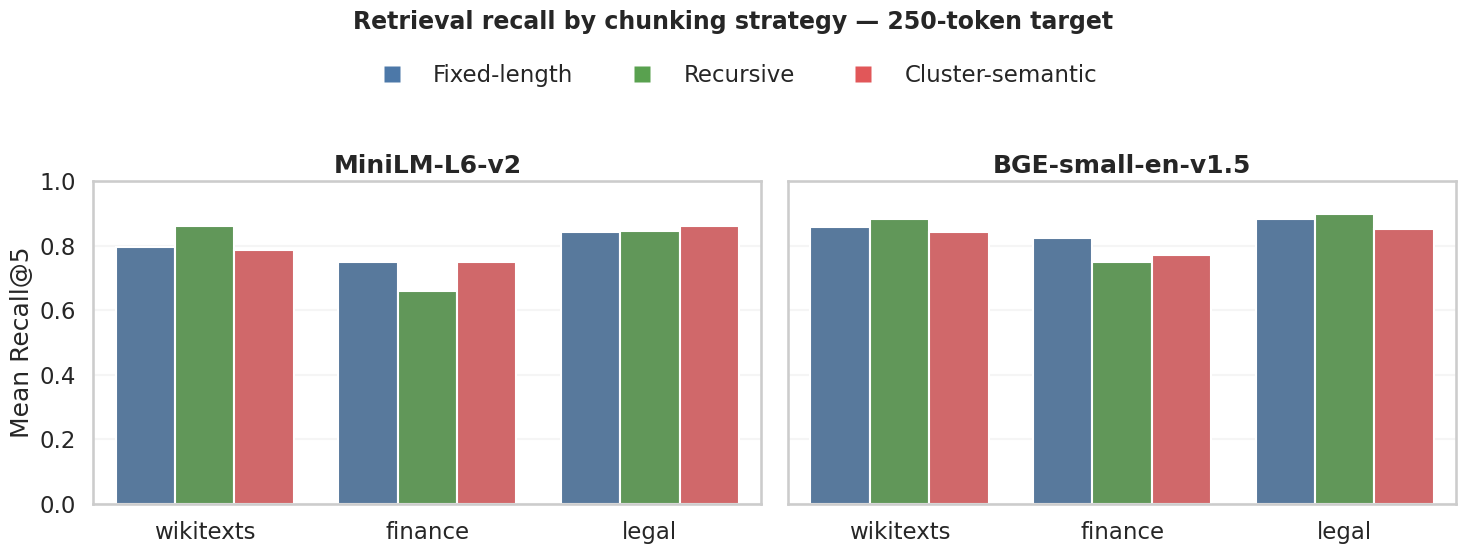

In [9]:
SIZE_FOR_COMPARISON = 250

domains = ["wikitexts", "finance", "legal"]
methods = ["Fixed-length", "Recursive", "Cluster-semantic"]

method_colors = {
    "Fixed-length": "#4C78A8",
    "Recursive": "#59A14F",
    "Cluster-semantic": "#E15759",
}

plot_df = results_df[
    results_df["chunk_size_target"] == SIZE_FOR_COMPARISON
].copy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5.5),
    sharey=True,
)

for ax, model_name in zip(
    axes,
    ["MiniLM-L6-v2", "BGE-small-en-v1.5"],
):
    sub = plot_df[
        plot_df["embedding_model"] == model_name
    ]

    sns.barplot(
        data=sub,
        x="domain",
        y="recall_mean",
        hue="method",
        hue_order=methods,
        palette=method_colors,
        errorbar=None,
        ax=ax,
    )

    ax.set_title(model_name, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(
        "Mean Recall@5" if ax is axes[0] else ""
    )
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.18)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.suptitle(
    "Retrieval recall by chunking strategy — 250-token target",
    fontsize=17,
    weight="bold",
    y=1.02,
)

legend_handles = [
    Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markerfacecolor=method_colors[m],
        markeredgecolor="none",
        markersize=11,
        label=m,
    )
    for m in methods
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    ncol=3,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.savefig(
    "/content/figures/fig1_recall_by_method.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

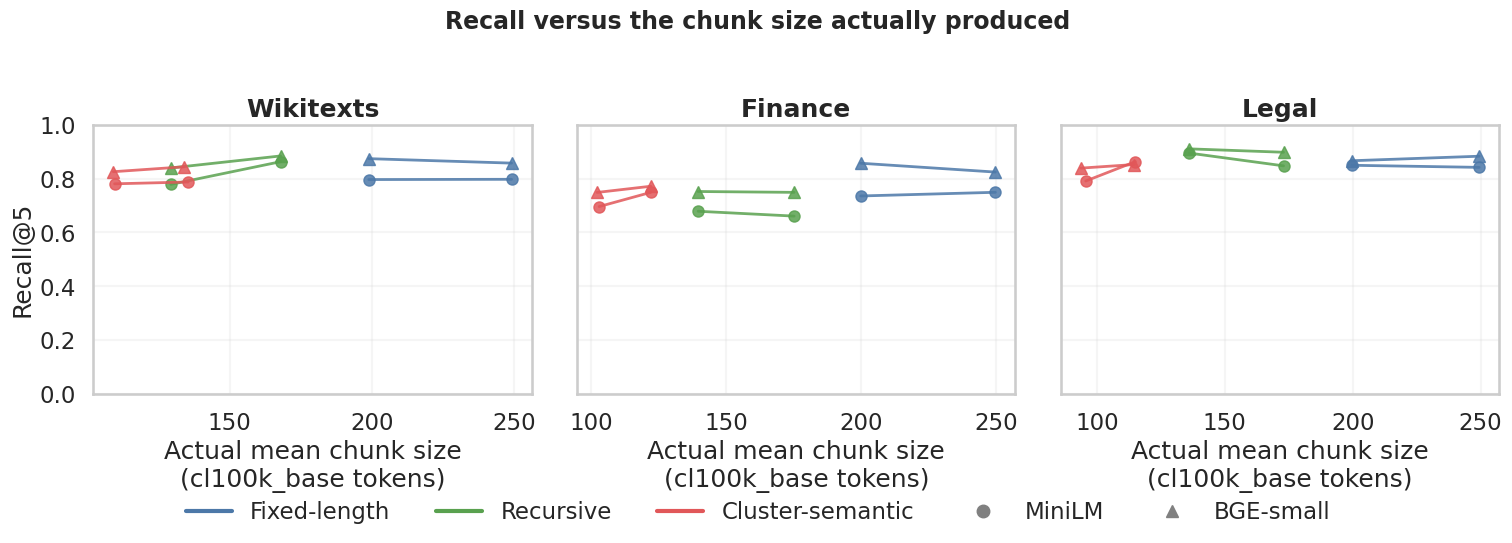

In [10]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15.5, 5),
    sharey=True,
)

for ax, domain in zip(axes, domains):
    sub = results_df[
        results_df["domain"] == domain
    ]

    for method in methods:
        for model_name, marker in {
            "MiniLM-L6-v2": "o",
            "BGE-small-en-v1.5": "^",
        }.items():
            m = sub[
                (sub["method"] == method) &
                (sub["embedding_model"] == model_name)
            ].sort_values("chunk_size_target")

            ax.plot(
                m["chunk_size_actual_mean"],
                m["recall_mean"],
                marker=marker,
                linewidth=2,
                markersize=8,
                color=method_colors[method],
                alpha=0.85,
            )

    ax.set_title(domain.capitalize(), weight="bold")
    ax.set_xlabel("Actual mean chunk size\n(cl100k_base tokens)")
    ax.grid(alpha=0.18)

axes[0].set_ylabel("Recall@5")
axes[0].set_ylim(0, 1)

method_handles = [
    Line2D(
        [0], [0],
        color=method_colors[m],
        lw=3,
        label=m,
    )
    for m in methods
]

model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        color="gray",
        markersize=9,
        label="MiniLM",
    ),
    Line2D(
        [0], [0],
        marker="^",
        linestyle="",
        color="gray",
        markersize=9,
        label="BGE-small",
    ),
]

fig.legend(
    handles=method_handles + model_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    frameon=False,
)

fig.suptitle(
    "Recall versus the chunk size actually produced",
    fontsize=17,
    weight="bold",
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    "/content/figures/fig2_recall_vs_actual_size.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

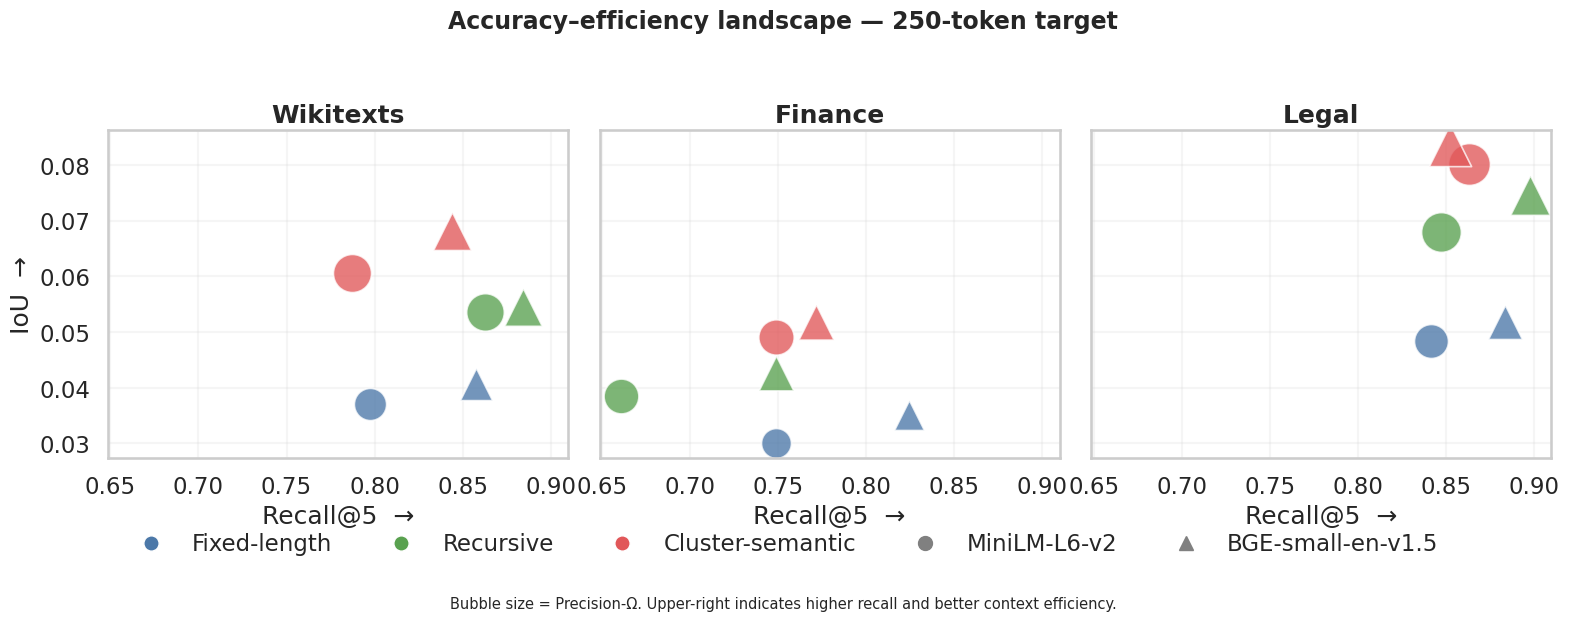

In [11]:
comp_df = results_df[
    results_df["chunk_size_target"] == 250
].copy()

model_markers = {
    "MiniLM-L6-v2": "o",
    "BGE-small-en-v1.5": "^",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5.3),
    sharex=True,
    sharey=True,
)

for ax, domain in zip(axes, domains):
    sub = comp_df[
        comp_df["domain"] == domain
    ]

    for _, row in sub.iterrows():
        ax.scatter(
            row["recall_mean"],
            row["iou_mean"],
            s=220 + 1700 * row["precision_omega_mean"],
            color=method_colors[row["method"]],
            marker=model_markers[row["embedding_model"]],
            alpha=0.78,
            edgecolor="white",
            linewidth=1.2,
        )

    ax.set_title(domain.capitalize(), weight="bold")
    ax.set_xlabel("Recall@5  →")
    ax.grid(alpha=0.18)

axes[0].set_ylabel("IoU  →")

fig.suptitle(
    "Accuracy–efficiency landscape — 250-token target",
    fontsize=17,
    weight="bold",
    y=1.03,
)

method_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=method_colors[m],
        markeredgecolor="white",
        markersize=11,
        label=m,
    )
    for m in methods
]

model_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        color="gray",
        markersize=10,
        label=model,
    )
    for model, marker in model_markers.items()
]

fig.legend(
    handles=method_handles + model_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=5,
    frameon=False,
)

fig.text(
    0.5,
    -0.10,
    "Bubble size = Precision-Ω. Upper-right indicates higher recall and better context efficiency.",
    ha="center",
    fontsize=10.5,
)

plt.tight_layout()

plt.savefig(
    "/content/figures/fig3_MAIN_accuracy_efficiency.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

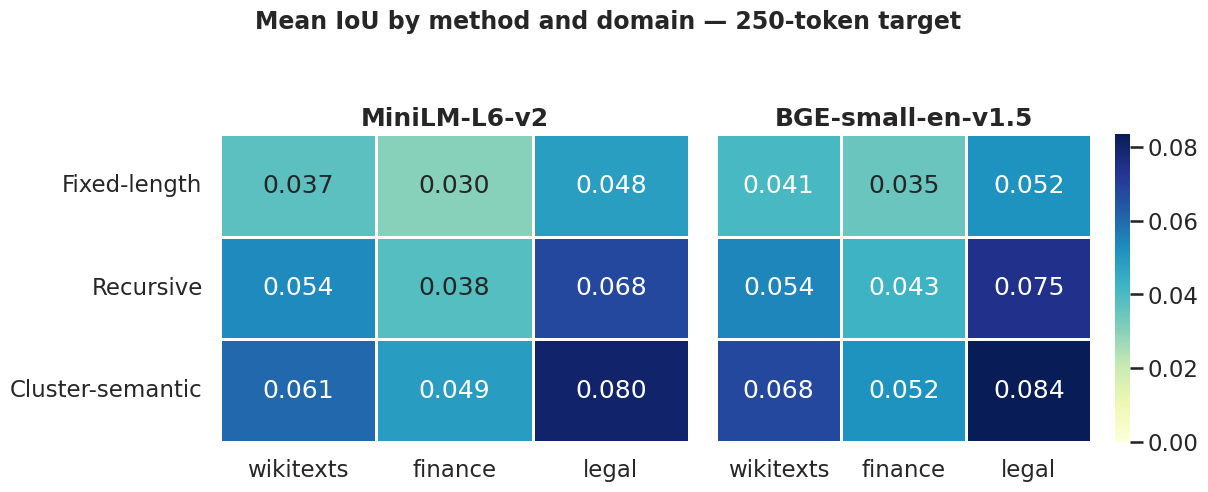

In [12]:
heat_df = results_df[
    results_df["chunk_size_target"] == 250
]

vmax = heat_df["iou_mean"].max()

fig, axes = plt.subplots(
    1, 2,
    figsize=(12.5, 4.8),
    sharey=True,
)

for ax, model_name in zip(
    axes,
    ["MiniLM-L6-v2", "BGE-small-en-v1.5"],
):
    sub = heat_df[
        heat_df["embedding_model"] == model_name
    ]

    pivot = (
        sub
        .pivot(
            index="method",
            columns="domain",
            values="iou_mean",
        )
        .reindex(methods)
        .reindex(columns=domains)
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        vmin=0,
        vmax=vmax,
        ax=ax,
        cbar=ax is axes[-1],
        linewidths=1,
        linecolor="white",
    )

    ax.set_title(model_name, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(
    "Mean IoU by method and domain — 250-token target",
    fontsize=17,
    weight="bold",
    y=1.04,
)

plt.tight_layout()

plt.savefig(
    "/content/figures/fig4_iou_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()